In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

from scipy.optimize import curve_fit

In [5]:
m = .2
a = 1
dimx = 16
dimt = 32
beta = 10
totalSteps = 50000

In [6]:
with open('50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [70]:
bIn = 500
skp = 500

gamma = np.array([[1j,0],[0,-1j]])
correlSigma3 = sim.correlation.GEVPStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearN1=4,kappa1=1.2,ti=1,momk=1)
correlSigma3Orig = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma)

100%|██████████| 99/99 [00:03<00:00, 24.97it/s]


In [78]:
effectiveMassSigma3 = sim.analysis.effectiveMassProp(correlSigma3,coshExpr=True)
effectiveMassSigma3Orig = sim.analysis.effectiveMassProp(correlSigma3Orig,coshExpr=True)

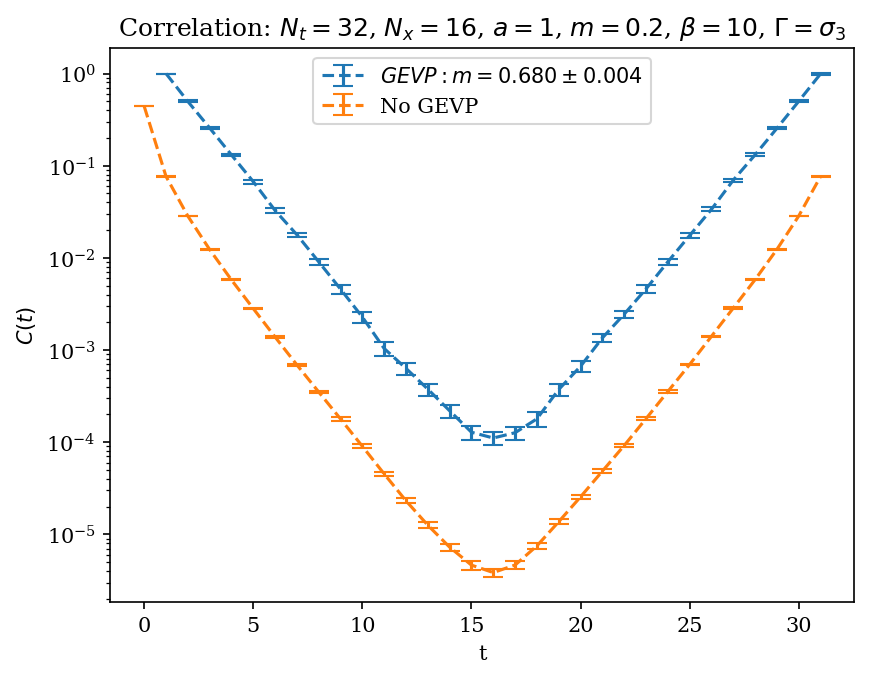

In [81]:
plt.figure(dpi=150)

masses = sim.correlation.gevpMassExtract(correlSigma3,fitT=6)
mPS=masses[0]
dmPS = masses[1]
plt.errorbar(x=np.arange(1,len(correlSigma3[0])+1),y=correlSigma3[0],yerr=correlSigma3[1],ls="--",capsize=5,label=rf"$GEVP: m={mPS:.3f}\pm{dmPS:.3f}$")
plt.errorbar(x=np.arange(len(correlSigma3Orig[0])),y=correlSigma3Orig[0],yerr=correlSigma3Orig[1],ls="--",capsize=5,label=r"No GEVP")

plt.semilogy()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")
plt.legend()

(0.0, 1.0)

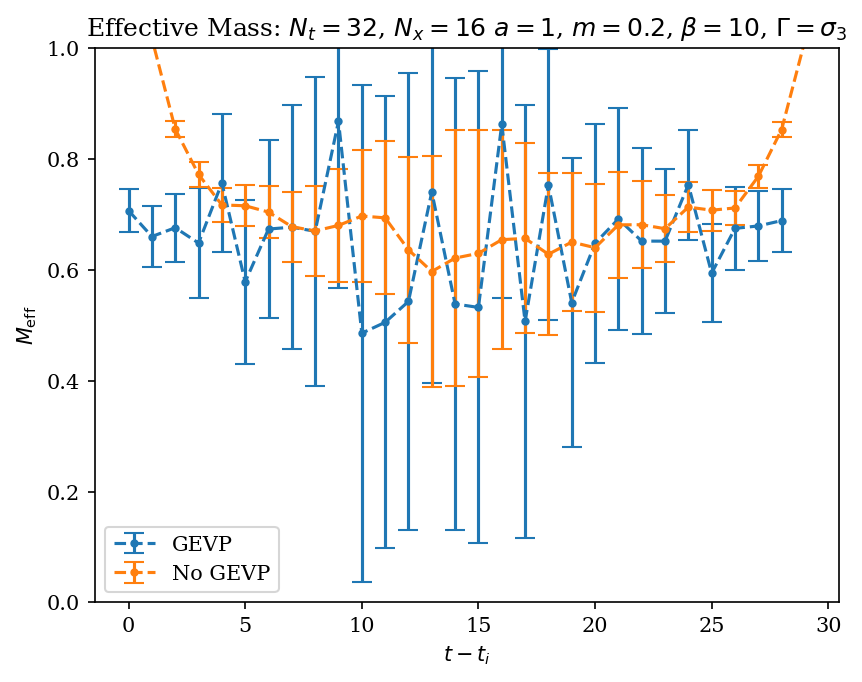

In [82]:
plt.figure(dpi=150)

plt.errorbar(x=np.arange(len(effectiveMassSigma3[0])),y=(effectiveMassSigma3[0]),yerr=effectiveMassSigma3[1],ls="--",marker=".",capsize=5,label=r"GEVP")
plt.errorbar(x=np.arange(len(effectiveMassSigma3Orig[0])),y=(effectiveMassSigma3Orig[0]),yerr=effectiveMassSigma3Orig[1],ls="--",marker=".",capsize=5,label=r"No GEVP")
plt.xlabel(r"$t-t_i$")
plt.xlabel(r"$t-t_i$")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$, $N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")
plt.legend()
plt.ylim([0,1])

In [67]:
ks = np.arange(3)
correls = []

for k in ks:
    correlSigma3 = sim.correlation.GEVPStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearN1=4,kappa1=4,ti=1,momk=k)
    correls.append(correlSigma3)

100%|██████████| 99/99 [00:49<00:00,  2.01it/s]


In [68]:
masses = []
for corr in correls:
    masses.append(sim.correlation.gevpMassExtract(corr,fitT=14))

np.array(masses)

array([[0.55420501, 0.00162748],
       [0.66932121, 0.00289852],
       [0.92515853, 0.05641724]])

Text(0.5, 1.0, 'Dispersion Relation: $N_t=32$, $N_x=16$, $a=1$, $m=0.2$, $\\beta=10$, $\\Gamma=\\sigma_3$')

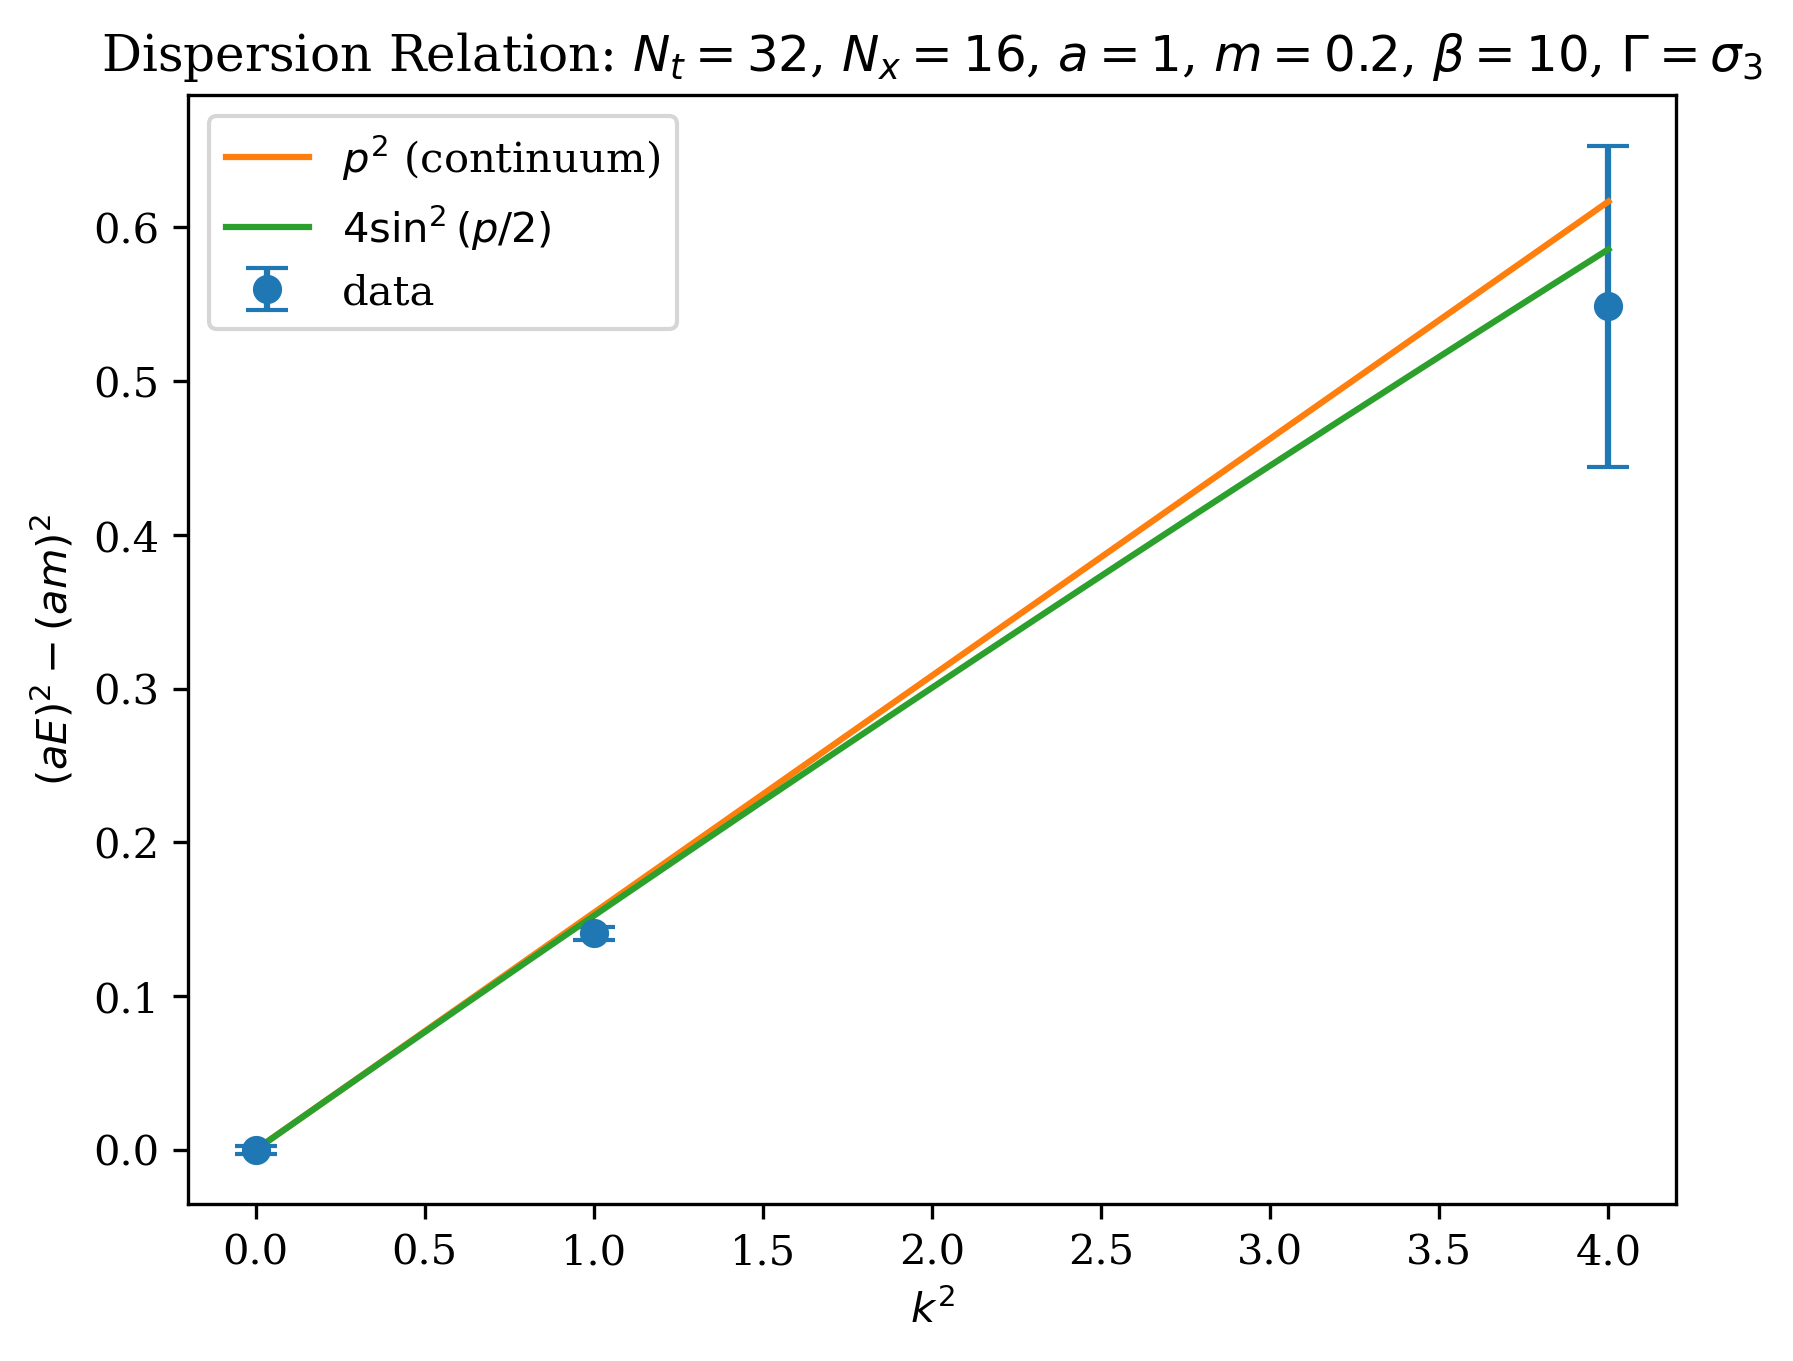

In [69]:
ps = (2*np.pi/dimx)*ks


masses = np.array(masses)
energyEstimates    = masses[:,0]
energyEstimatesErr = masses[:,1]

kineticDispersion = energyEstimates**2 - energyEstimates[0]**2
dispErr = 2*np.sqrt((energyEstimates*energyEstimatesErr)**2
                    + (energyEstimates[0]*energyEstimatesErr[0])**2)

# fine grid for smooth curves
k_fine = np.linspace(0, ks.max(), 400)
p_fine = (2*np.pi/dimx)*k_fine
m_phys = energyEstimates[0]

plt.figure(dpi=300)
plt.errorbar(ks**2, kineticDispersion, yerr=dispErr, capsize=5, ls="", marker="o", label="data")
plt.plot(k_fine**2, p_fine**2, label=r"$p^2$ (continuum)")
plt.plot(k_fine**2, 4*np.sin(p_fine/2)**2, label=r"$4\sin^2(p/2)$")
plt.xlabel("$k^2$")
plt.ylabel(r"$(aE)^2-(am)^2$")
plt.legend()
plt.title(rf"Dispersion Relation: $N_t={dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")